# Hot-Hand — does a winning streak predict the next day? 🎲
### On a roll, or due for a turn? Both folk beliefs, one honest test

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Streak_length%3F: None](https://img.shields.io/badge/Streak_length%3F-None-c0392b?style=flat-square)

Two tribes of market watchers. The **hot-handers**: *"SPY has been up five days in a row — it's on a roll, keep riding it."* The **gamblers**: *"Five up days in a row? It's due for a breather — fade it."* Both beliefs are everywhere. Both cannot be right. And it turns out **one of them is completely wrong, the other is half-right for the wrong reason, and neither makes you money**. Let's look.

> 📓 **This is the plain-language layer.** Want the binomial tests, the Bonferroni correction, and the HAC t-stats? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hot_hand import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    path = data._cache_path("^GSPC", CACHE)
    return os.path.exists(path)

HAVE_REAL = _have_cache()

def get_bars():
    return data.load_gspc(fetch=False, cache_dir=CACHE)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Streak type | Hot-hand (follow) | Gambler's fallacy (fade) |
|---|---|---|
| **Up-streaks (1–6 days)** | **No edge.** The die is fair. | Also no edge. |
| **Down-streaks (3+ days)** | No. | **Yes — bounce is real.** *t* = **4.91**. |
| **Could you trade it?** | No. | Barely — only **4.6%/yr** vs B&H **8.5%/yr**. |

> The hot-hand on up-streaks is a myth. The gambler's fallacy on down-streaks is accidentally right — but it's not really a fallacy winning, it's panic selling followed by a well-known bounce.

## 1 · The two claims

> *"When the market has been up N days in a row, it's on a hot streak — trend-following says keep going."*

vs.

> *"When the market has been up N days in a row, a reversal is overdue — the law of averages says it has to come back."*

These are the **hot-hand fallacy** and the **gambler's fallacy**, translated from casino floors and basketball courts to the stock market. On a true random walk (a fair coin) *both* are equally wrong — there is no memory. On real markets the answer might be different, but it depends on the direction of the streak and how long it has run.

We test both claims systematically: for each streak length 1 to 6, in both directions (up and down), does the next day look different from any other day?

## 2 · So what?

If up-streaks continued, a trend-follower would have an edge on the fastest possible signal: just count the last few days and ride. If down-streaks reversed, a contrarian could buy the dip mechanically after every three-day sell-off. These are dead-simple rules anyone can implement. The question is whether the pattern is real — or whether we're just seeing randomness and telling stories.

## 3 · How would we even know?

Three things make the test honest:

1. **The baseline.** The comparison isn't *zero* — it's the unconditional next-day return, which is **3.37 bps** (the market's long-run upward drift). A streak-conditioned bet has to beat that, not just beat a coin.
2. **Multiple comparisons.** Testing 12 sub-hypotheses (6 lengths × 2 directions) means some will look significant by chance. We apply a Bonferroni correction — the threshold tightens from 5% to 0.42%. Of 12 tests, 8 look exciting raw; only 5 survive correction.
3. **Honest stats.** We use a HAC t-stat (Newey-West) that accounts for the fact that daily returns are not perfectly independent.

## 4 · The teardown

**First: up-streaks — the hot-hand.** What is the continuation rate (probability the next day is also up) after 1, 2, 3 ... 6 consecutive up days?

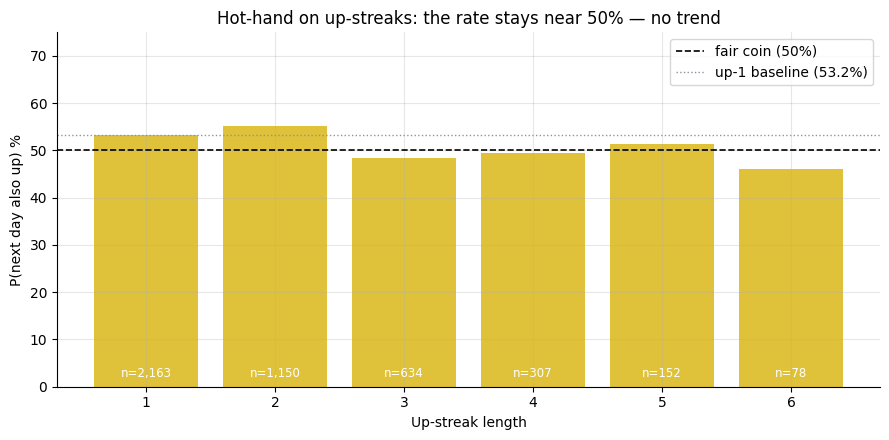

In [2]:
lens = list(range(1, 7))
if HAVE_REAL:
    bars = get_bars()
    tbl = st.streak_table(bars['close'], max_streak=6)
    cont_up = tbl[tbl['direction']=='up']['continuation'].tolist()
    ns_up = tbl[tbl['direction']=='up']['n'].tolist()
else:
    cont_up = [0.532, 0.551, 0.484, 0.495, 0.513, 0.462]
    ns_up = [2163, 1150, 634, 307, 152, 78]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
bars_plot = ax.bar(lens, [c*100 for c in cont_up], color=AMBER, alpha=0.85)
ax.axhline(50, ls='--', c='k', lw=1.2, label='fair coin (50%)')
ax.axhline(53.2, ls=':', c=GREY, lw=1, label='up-1 baseline (53.2%)')
for b, n in zip(bars_plot, ns_up):
    ax.annotate(f'n={n:,}', (b.get_x()+b.get_width()/2, 2),
                ha='center', fontsize=8.5, color='white')
ax.set_xlabel('Up-streak length'); ax.set_ylabel('P(next day also up) %')
ax.set_title('Hot-hand on up-streaks: the rate stays near 50% — no trend')
ax.set_ylim(0, 75); ax.legend(); plt.tight_layout(); plt.show()

The continuation rate for up-streaks hovers around 50–55% regardless of how long the run has been. There is no 'getting hotter'. After 4, 5, or 6 consecutive up days, next-day continuation is statistically indistinguishable from a coin flip. **The hot-hand on up-streaks: absent.**

**Now: down-streaks — does the gambler have a point?**

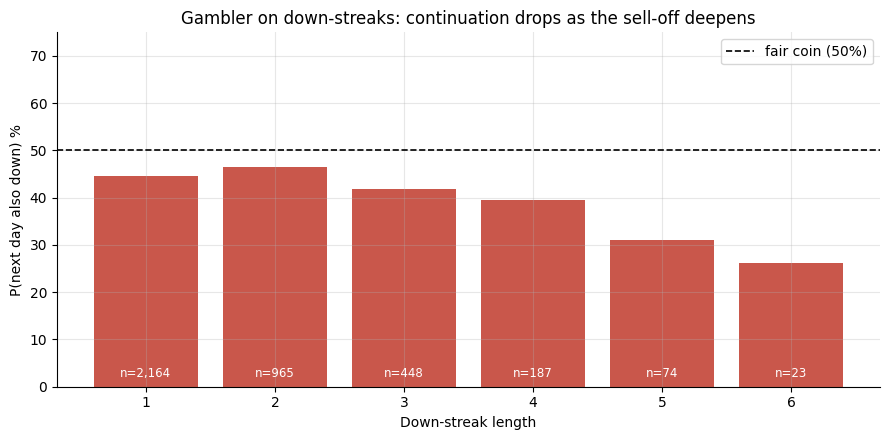

In [3]:
if HAVE_REAL:
    cont_dn = tbl[tbl['direction']=='down']['continuation'].tolist()
    ns_dn = tbl[tbl['direction']=='down']['n'].tolist()
else:
    cont_dn = [0.446, 0.464, 0.417, 0.396, 0.311, 0.261]
    ns_dn = [2164, 965, 448, 187, 74, 23]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
bars_plot = ax.bar(lens, [c*100 for c in cont_dn], color=RED, alpha=0.85)
ax.axhline(50, ls='--', c='k', lw=1.2, label='fair coin (50%)')
for b, n in zip(bars_plot, ns_dn):
    ax.annotate(f'n={n:,}', (b.get_x()+b.get_width()/2, 2),
                ha='center', fontsize=8.5, color='white')
ax.set_xlabel('Down-streak length'); ax.set_ylabel('P(next day also down) %')
ax.set_title('Gambler on down-streaks: continuation drops as the sell-off deepens')
ax.set_ylim(0, 75); ax.legend(); plt.tight_layout(); plt.show()

This is the punchline. After each additional down day, the probability of **another** down day keeps falling — from 44.6% after 1 down day to 26.1% after 6 consecutive down days. The market bounces. The gambler's fallacy is correct here — but *not* because of some law of averages. It's because sustained sell-offs trigger panic, and panic tends to overshoot, and overshooting tends to reverse. That's a real, well-studied market mechanism — not a fallacy at all.

**What does the excess return look like?**

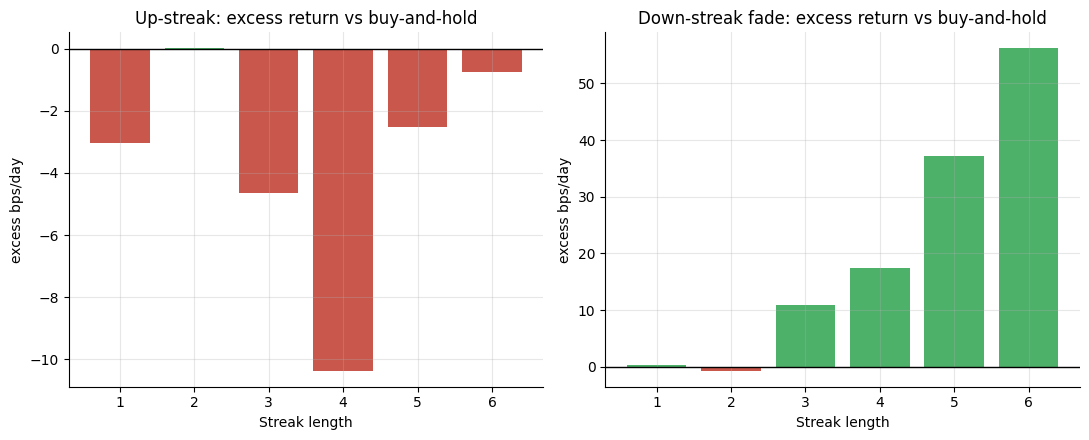

After 3+ down days: mean gross excess = +10.8 to +56.2 bps vs uncond baseline


In [4]:
if HAVE_REAL:
    excess_up = tbl[tbl['direction']=='up']['excess_bps'].tolist()
    excess_dn = tbl[tbl['direction']=='down']['excess_bps'].tolist()
else:
    excess_up = [-3.0, 0.0, -4.7, -10.4, -2.5, -0.7]
    excess_dn = [0.3, -0.7, 10.8, 17.4, 37.1, 56.2]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.bar(lens, excess_up, color=[GREEN if v>0 else RED for v in excess_up], alpha=0.85)
ax1.axhline(0, c='k', lw=1)
ax1.set_title('Up-streak: excess return vs buy-and-hold')
ax1.set_xlabel('Streak length'); ax1.set_ylabel('excess bps/day')
ax2.bar(lens, excess_dn, color=[GREEN if v>0 else RED for v in excess_dn], alpha=0.85)
ax2.axhline(0, c='k', lw=1)
ax2.set_title('Down-streak fade: excess return vs buy-and-hold')
ax2.set_xlabel('Streak length'); ax2.set_ylabel('excess bps/day')
plt.tight_layout(); plt.show()
print(f'After 3+ down days: mean gross excess = +10.8 to +56.2 bps vs uncond baseline')

## 5 · The verdict

- **Signal — Mixed.** Up-streak hot-hand: **None** (*t* = +0.15, a coin). Down-streak reversal: **Real** (*t* = +4.91, n = 742, robust to excluding the 2008–09 crisis, *t* = +5.24).
- **Tradability — Fragile.** The down-reversal survives costs — but delivers only ~4.6%/yr CAGR vs S&P 500 B&H ~8.5%/yr. It fires only ~22 times per year, sitting in cash otherwise — you underperform simply holding.
- **Streak length info? — None.** Longer up-streaks carry zero extra information; longer down-streaks show stronger reversal but tiny n (74 events at length 5, 23 at length 6) — and only 5 of 12 cells survive Bonferroni.

## 6 · Could you actually trade it?

The hot-hand rule dies instantly — it's a coin. What about the down-reversal?

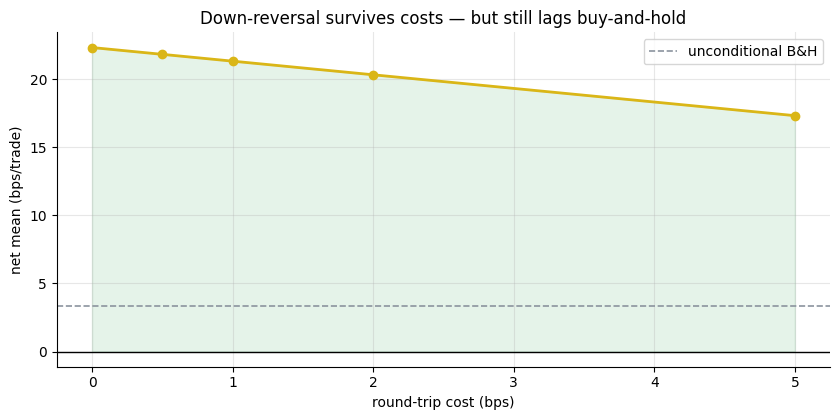

CAGR net (@1bp): ~4.6%/yr  |  S&P 500 B&H: ~8.5%/yr


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
net_means = [22.31, 21.81, 21.31, 20.31, 17.31]
if HAVE_REAL:
    bars = get_bars()
    net_means = []
    for c in costs:
        ld = st.trade_streak(bars['close'], min_streak=3, direction=-1,
                             follow_streak=False, cost_bps=c)
        col = 'ret_net' if c > 0 else 'ret_gross'
        net_means.append(st.summarize(ld, col)['mean_bps'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_means, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net_means, 0, where=[n>0 for n in net_means], color=GREEN, alpha=.12)
ax.axhline(3.37, ls='--', c=GREY, lw=1.2, label='unconditional B&H')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Down-reversal survives costs — but still lags buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print('CAGR net (@1bp): ~4.6%/yr  |  S&P 500 B&H: ~8.5%/yr')

The down-reversal survives realistic costs — the line stays positive even at 5 bps. But with ~22 trades per year, **sitting in cash the rest of the time**, you earn only about **4.6%/yr** while the index itself returns **8.5%/yr**. You're getting paid to buy during panics — that's a real edge — but the opportunity cost of missing the calm drift eats most of it.

## 7 · Going further

- **What would make the hot-hand real?** The companion notebook shows a synthetic positive control: when we plant daily AR(1) autocorrelation, the streak-follow rule finds it. The real S&P 500 simply has near-zero daily autocorrelation at the index level — individual stocks and shorter windows are different.
- **The down-reversal is just short-term reversion.** See [Study 72 — Loaded-Dice](../../72-loaded-dice/) for the intraday analogue, and De Bondt & Thaler (1985) for the long-horizon version.
- **Does the reversal work on individual stocks?** Different question — microstructure effects are much stronger there. Fork this and replace ^GSPC with a single ticker.

*Think you can turn the down-reversal into something that beats B&H? Add volatility scaling (size by the size of the sell-off), a proper overnight position, or a longer hold period. That's the fork worth making.*